In [1]:
import torch as tc
import numpy as np
import qutip as qt
import function as my
import mixfunn as mf
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]

def Field(t):
    return (1.5 * np.sin(2.0 * t) + 0.8 * np.cos(3.5 * t + 0.5) + 0.4 * np.sin(7.0 * t))


def data_qubit(O_op,tlist,field,device="cpu"):
    # Lista de tempos para a evolução
    H0 = 0.5*qt.sigmaz()
    H1 = 0.5*qt.sigmax()
    H  = [H0,[H1,field(tlist)]]
    
    # Hamiltonian Lindbladian
    c_ops = []
    
    # Estado inicial (cada qubit na superposição de |0> e |1>)
    # |+> = (|0> + |1>)/sqrt(2)
    theta1  = np.pi/4
    phi1    = 0.0 #np.pi/3
    ket_plus1 = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))
    psi0 = ket_plus1
    
    # Solução da equação de Schrödinger
    options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
    result  = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=O_op,options=options)

    expect  = tc.tensor( np.array( result.expect),device = device).transpose(0, 1)
    return expect


/home/gubio/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


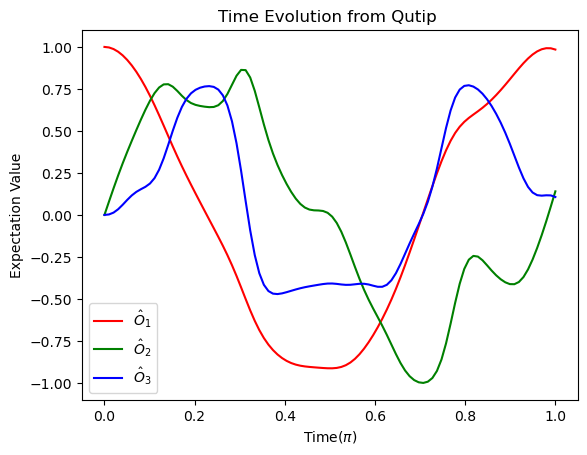

In [3]:
tfinal      = 2.52*np.pi
N           = 100
Nedo        = 3

tlist = np.linspace(0.0, tfinal, N)
valor_esperado_data  = data_qubit(O_op,tlist,Field,device="cpu")

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(tlist/tfinal,
             valor_esperado_data[:,i].cpu() ,
             label=fr"$\hat{{O}}_{{{i+1}}}$",
             color=colors[i])
    
plt.xlabel(r'Time($\pi$)')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from Qutip ')
plt.show()

In [4]:
time = tc.linspace(
    0, tfinal, N,
    dtype = tc.float32,
    requires_grad = True).reshape((-1, 1))

X_vector = my.Rede(
    neuronio   = [15,15],
    input_     = 1,
    output_    = 3,
    activation =[mf.SIN(), mf.SIN()])

mixfunn_field = mf.MixFunn(
    N_layers = 2,
    N_neuro = 7,
    second_order_function = False)

opt = tc.optim.Adam(list(mixfunn_field.parameters())+list(X_vector.parameters()), lr=0.1, betas=(0.9,0.9))

JZ = 1e0
JY = 0e0
epocas  = 30000

100%|██████████| 30000/30000 [00:56<00:00, 531.71it/s]


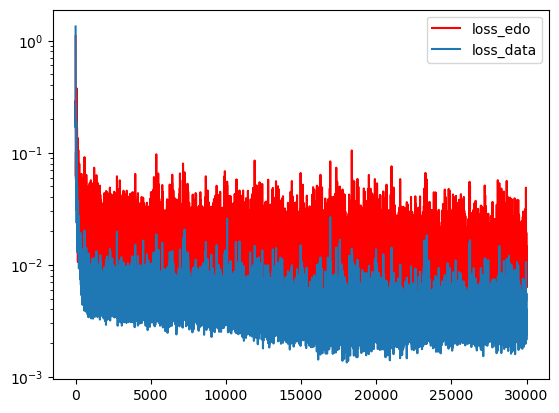

In [5]:
LOSS    = []
LOSS1   = []
LOSS2   = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    ####### Forward pass #######
    y   = X_vector(time)    # [N,3]
    JX  = mixfunn_field(time)   # [N,1]

    ######## Loss edo #######
    dX_dt = []
    for i in range(y.shape[1]):
        dX_dt.append(
            tc.autograd.grad(
                outputs = y[:, i],
                inputs = time,
                grad_outputs = tc.ones_like(y[:, i]),
                #retain_graph = True,
                create_graph = True)[0])
    dX_dt   = tc.cat(dX_dt, dim=1)
    
    X,Y,Z = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    LOSS_edo  = 0
    
    LOSS_edo += (dX_dt[:,0:1] - (-1.0*Y))**2
    LOSS_edo += (dX_dt[:,1:2] - ( 1.0*X - 1.0*JX*Z))**2
    LOSS_edo += (dX_dt[:,2:3] - ( 1.0*JX*Y))**2
    LOSS_edo = LOSS_edo.mean()


    ####### loss data(expected values) #######
    LOSS_data=0    
    LOSS_data +=(y[:,0:1]  - valor_esperado_data[:,0:1])**2 
    LOSS_data +=(y[:,1:2]  - valor_esperado_data[:,1:2])**2 
    LOSS_data +=(y[:,2:3]  - valor_esperado_data[:,2:3])**2 
    LOSS_data = LOSS_data.mean()
    

    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data 

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()

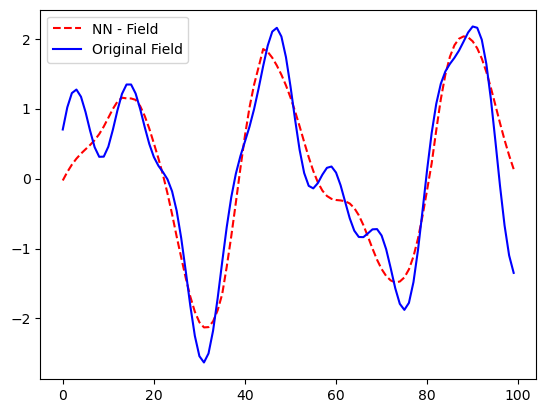

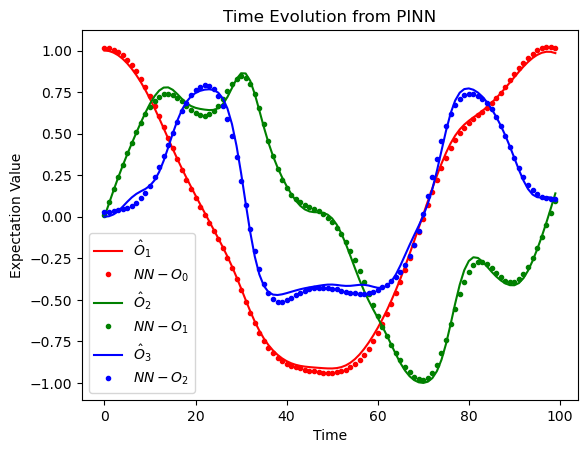

In [6]:
t_points = np.linspace(0,tfinal, N)
JX =  mixfunn_field(time).detach().numpy()

field_original=Field(t_points)
plt.plot(JX,"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

X_vector.eval()
X_  = X_vector(time).detach().numpy()

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    plt.plot(X_[:,i],"." ,label=fr"$NN - O_{{{i}}}$", color=colors[i])
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from PINN')
plt.show()


/home/gubio/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


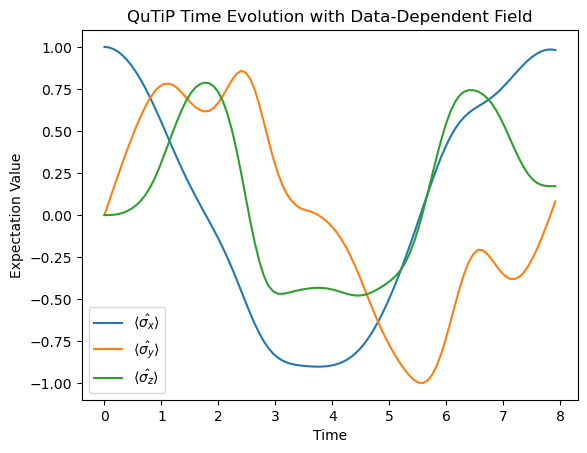

In [7]:
H0 = .5*qt.sigmaz()
H1 = .5*qt.sigmax()
# The full Hamiltonian is defined as a list: 
# H = H0 + f(t) * H1, where f(t) is the field data
H = [H0, [H1, JX.flatten()]] # QuTiP uses cubic spline interpolation for field_data

# (Optional) Define collapse operators for an open system simulation
c_ops = [] # e.g., c_ops = [np.sqrt(gamma) * qt.sigmam()]

# 3. Define the initial state and expectation value operators
theta1  = np.pi/4
phi1    = 0.0 #np.pi/3
psi0    = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))

O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]

# 4. Simulate the time evolution
options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
result  = qt.mesolve(H, psi0, t_points, c_ops=c_ops, e_ops=O_op,options=options)

# 5. Plot the results
plt.figure()
plt.plot(t_points, result.expect[0], label=r'$\langle \hat{\sigma_x}\rangle$')
plt.plot(t_points, result.expect[1], label=r'$\langle \hat{\sigma_y}\rangle$')
plt.plot(t_points, result.expect[2], label=r'$\langle \hat{\sigma_z}\rangle$')

plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('QuTiP Time Evolution with Data-Dependent Field')
plt.show()

# prunning 

In [8]:
p = mixfunn_field.layers1.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
p

tensor([[2.5194e-04, 1.2537e-03, 6.3383e-04, 1.3089e-04, 2.2760e-02, 4.5997e-02,
         3.8426e-04],
        [2.0616e-04, 1.0454e-02, 2.5034e-02, 1.9293e-03, 1.0330e-05, 3.5609e-02,
         3.7154e-02],
        [2.6877e-02, 1.3920e-01, 6.1727e-02, 1.4725e-01, 1.6810e-02, 5.2645e-02,
         3.2438e-02],
        [2.2475e-03, 1.1643e-03, 8.9652e-03, 1.2100e-03, 1.1954e-03, 7.2316e-03,
         1.3893e-03],
        [1.3316e-02, 3.7679e-02, 3.0560e-02, 2.6295e-02, 1.1790e-02, 3.3877e-02,
         1.8997e-02],
        [3.3816e-02, 2.0912e-02, 2.3399e-03, 4.7391e-03, 3.7586e-02, 3.6585e-02,
         5.0193e-03],
        [1.9931e-04, 1.3481e-03, 1.0742e-03, 2.0396e-04, 7.4057e-04, 3.6787e-04,
         3.9798e-04]])

In [9]:
import torch.nn.utils.prune as prune
prune.l1_unstructured(mixfunn_field.layers1.project1.linear, 'weight', amount=0.1)
prune.l1_unstructured(mixfunn_field.layers1.project1.linear, 'bias', amount=0.1)

prune.l1_unstructured(mixfunn_field.layers2.project1.linear, 'weight', amount=0.1)
prune.l1_unstructured(mixfunn_field.layers2.project1.linear, 'bias', amount=0.1)

p = mixfunn_field.layers1.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
mixfunn_field.layers1.p.data = tc.where(p < 0.01, 0.0, mixfunn_field.layers1.p.data)

p = mixfunn_field.layers1.p.data
L = tc.sum(abs(p))
p = abs(p)/L

values, indices = tc.sort(p)
mask = tc.zeros(indices.shape[1])
for k in range(indices.shape[1]):
    if k > int(0.2*indices.shape[1]):
        mask[indices[0][k]] = 1.0
mixfunn_field.layers1.p.data = mask*mixfunn_field.layers1.p.data
print(mixfunn_field.layers1.p.data)

p = mixfunn_field.layers2.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
mixfunn_field.layers2.p.data = tc.where(p < 0.01, 0.0, mixfunn_field.layers2.p.data)

p = mixfunn_field.layers2.p.data
L = tc.sum(abs(p))
p = abs(p)/L

values, indices = tc.sort(p)
mask2 = tc.zeros(indices.shape[1])
for k in range(indices.shape[1]):
    if k > int(0.2*indices.shape[1]):
        mask2[indices[0][k]] = 1.0
mixfunn_field.layers2.p.data = mask2*mixfunn_field.layers2.p.data
print(mixfunn_field.layers2.p.data)


tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -0.8753, -1.7690,  0.0000],
        [ 0.0000,  0.0000,  0.9628,  0.0000,  0.0000, -1.3695, -1.4289],
        [ 0.0000, -0.0000, -2.3740, -5.6631,  0.6465,  2.0247,  1.2475],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [-0.0000,  0.0000,  1.1753,  1.0113, -0.4534,  1.3029,  0.7306],
        [ 0.0000, -0.0000,  0.0000,  0.0000,  1.4455, -1.4070,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]])
tensor([[ 0.4808,  0.9702, -2.0363,  1.4520, -0.4091,  0.0000,  0.0000]])


100%|██████████| 50000/50000 [01:33<00:00, 532.71it/s]


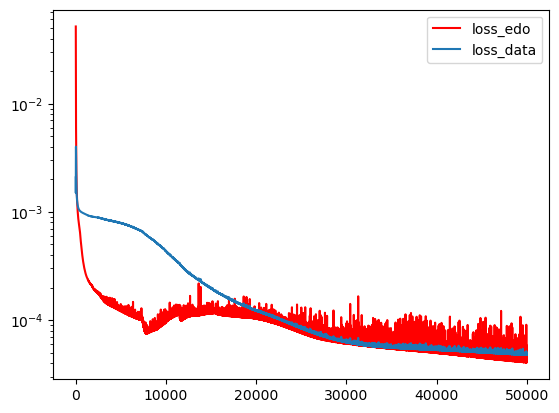

In [10]:
opt = tc.optim.Adam(
    list(mixfunn_field.parameters())+list(X_vector.parameters()),
    lr=0.001)

JZ = 1e0
JY = 0e0

epocas  = 50000

LOSS    = []
LOSS1   = []
LOSS2   = []
for _ in tqdm(range(epocas)):
    # aplicaçao da mascara para os pesos novos
    mixfunn_field.layers1.p.data = mask*mixfunn_field.layers1.p.data
    mixfunn_field.layers2.p.data = mask2*mixfunn_field.layers2.p.data

    ####### Forward pass #######
    y   = X_vector(time)    # [N,3]
    JX  = mixfunn_field(time)   # [N,1]

    ######## Loss edo #######
    dX_dt = []
    for i in range(y.shape[1]):
        dX_dt.append(
            tc.autograd.grad(
                outputs = y[:, i],
                inputs = time,
                grad_outputs = tc.ones_like(y[:, i]),
                #retain_graph = True,
                create_graph = True)[0])
    dX_dt   = tc.cat(dX_dt, dim=1)
    
    X,Y,Z = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    LOSS_edo  = 0
    
    LOSS_edo += (dX_dt[:,0:1] - (-1.0*Y))**2
    LOSS_edo += (dX_dt[:,1:2] - ( 1.0*X - 1.0*JX*Z))**2
    LOSS_edo += (dX_dt[:,2:3] - ( 1.0*JX*Y))**2
    LOSS_edo = LOSS_edo.mean()


    ####### loss data(expected values) #######
    LOSS_data=0    
    LOSS_data +=(y[:,0:1]  - valor_esperado_data[:,0:1])**2 
    LOSS_data +=(y[:,1:2]  - valor_esperado_data[:,1:2])**2 
    LOSS_data +=(y[:,2:3]  - valor_esperado_data[:,2:3])**2 
    LOSS_data = LOSS_data.mean()
    

    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data 

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()

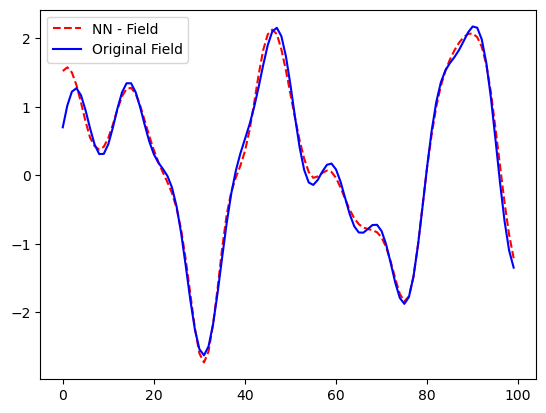

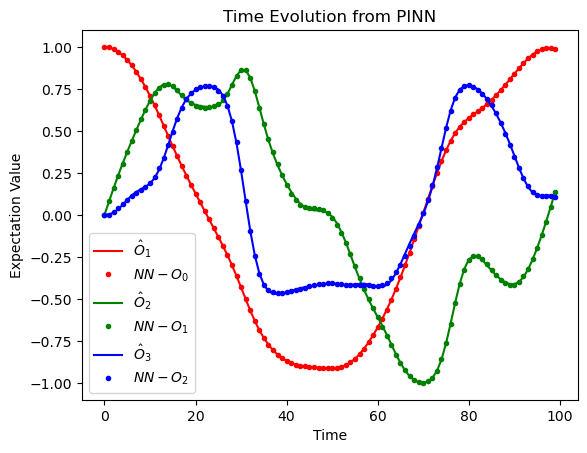

In [11]:
t_points = np.linspace(0,tfinal, N)
JX =  mixfunn_field(time).detach().numpy()

field_original=Field(t_points)
plt.plot(JX,"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

X_vector.eval()
X_  = X_vector(time).detach().numpy()

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    plt.plot(X_[:,i],"." ,label=fr"$NN - O_{{{i}}}$", color=colors[i])
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from PINN')
plt.show()


In [12]:
asasa

NameError: name 'asasa' is not defined

## Expressão analitica

In [ ]:
import sympy
from sympy import symbols, Matrix
from sympy import symbols, sin, cos, exp, Abs, sqrt, log, Piecewise

# Define the equivalent SymPy functions
def Sin(x):
    return sin(x)

def Cos(x):
    return cos(x)

def Exp(x):
    return exp(x)

def ExpN(x):
    return exp(-x)

def ExpAbs(x):
    return exp(-0.01 * Abs(x))

def ExpAbsP(x):
    return exp(0.01 * Abs(x))

def Sqrt(x):
    #Approximation of square root to avoid instability
    relu = Piecewise((x, x > 0), (0, True))  # ReLU equivalent
    return sqrt(0.01 + relu)

def Log(x):
    #Approximation of log to avoid instability
    relu = Piecewise((x, x > 0), (0, True))  # ReLU equivalent
    return log(0.1 + relu)

def Id(x):
    return x

# Create the list of symbolic functions
functions = [Sin, Cos, ExpAbs, ExpAbsP, Sqrt, Log, Id]

# functions = [Sin, Cos, Id]

In [ ]:
mixfunn_field.layers.p.data

In [ ]:
#(optional) prune parameters
# prune.l1_unstructured(mixfunn_field.layers.project1.linear, 'weight', amount=0.01)

p = mixfunn_field.layers.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
mixfunn_field.layers.p.data = tc.where(p < 0.01, 0.0, mixfunn_field.layers.p.data)

# Define the symbols for the input
t = symbols('t')

# Define the input vector
inputs = Matrix([t])

#If second-order in the input, append the product between the inputs
if mixfunn_field.layers.project1.second_order:
    inputs = Matrix.vstack(inputs, Matrix([t]))
inputs

Argumentos das funçoes 

In [ ]:
w = mixfunn_field.layers.project1.linear.weight.data.cpu().numpy()
b = mixfunn_field.layers.project1.linear.bias.data.cpu().numpy().reshape((w.shape[0], 1))

result = (w @ inputs) + b
result = result.reshape(mixfunn_field.layers.n_out, len(functions))
result.T

Aplicando a funçao de ativaçao 

In [ ]:
# Apply each function to the result vector
result2 = Matrix([[functions[i](elem) for elem in result[:, i]] for i in range(len(functions))])
result2

In [ ]:
mixfunn_field.layers.p

In [ ]:
np.array(result2)

In [ ]:
tc.sum(p * x, axis=2)

In [ ]:
p = mixfunn_field.layers.p.data
p = p.detach().cpu().numpy().T.round(2) #arrendondar para 2 casas decimais

result3 = Matrix(p * (np.array(result2)))
result3

In [ ]:
result4 = Matrix([sum(result3.col(i)) for i in range(result3.cols)])
final_expression = result4[0]
final_expression

In [ ]:
f_numeric = sympy.lambdify(t, final_expression, "numpy")
field_value = f_numeric(time.detach().cpu().numpy().flatten())
plt.plot(time.detach().cpu().numpy().flatten(), field_value, label="Final Expression")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
f_numeric = sympy.lambdify(t, final_expression, "numpy")
time = tc.linspace(0, tfinal*2, N)
field_value = f_numeric(time.detach().cpu().numpy().flatten())
plt.plot(time.detach().cpu().numpy().flatten(), field_value, label="Final Expression")
plt.legend()
plt.grid(True)
plt.show()